In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

# --- Meteorological: monthly HDD ---
met1 = pd.read_csv("data/meteorological_observations_1_1_2022-11_24_2024.csv", parse_dates=["time"])
met2 = pd.read_csv("data/meteorological_observations_11_27_2024-3_31_2026.csv", parse_dates=["time"])
met = pd.concat([met1, met2], ignore_index=True).sort_values("time").reset_index(drop=True)

met["temp_f"] = met["temp"] * 9 / 5 + 32
daily_mean_f = met.resample("D", on="time")["temp_f"].mean()
daily_hdd = np.maximum(0, 65 - daily_mean_f)
monthly_hdd = daily_hdd.resample("ME").sum().rename("hdd")

# --- Electric: monthly kWh ---
elec1 = pd.read_csv("data/UsageData-01_01_2022-11_26_2024-clean.csv", parse_dates=["timestamp"])
elec2 = pd.read_csv("data/UsageData-11_27_2024-03_31_2026-clean.csv", parse_dates=["timestamp"])
elec2["timestamp"] = pd.to_datetime(elec2["timestamp"], utc=True).dt.tz_convert("America/New_York").dt.tz_localize(None)
elec = pd.concat([elec1, elec2], ignore_index=True).sort_values("timestamp").reset_index(drop=True)

monthly_kwh = elec.resample("ME", on="timestamp")["kwh"].sum().rename("kwh")

# --- Merge and random 75/25 split ---
df = pd.merge(monthly_hdd, monthly_kwh, left_index=True, right_index=True).dropna()

train, test = train_test_split(df, test_size=0.25, random_state=42)

print(f"Total: {len(df)} months")
print(f"Train: {len(train)} months")
print(f"Test:  {len(test)} months")
df.head()

Total: 51 months
Train: 38 months
Test:  13 months


,hdd,kwh
time,,
2022-01-31,1388.9925,1754.688
2022-02-28,1064.5575,1464.997
2022-03-31,940.2300,1682.081
2022-04-30,601.3650,1370.427
2022-05-31,293.3550,594.148


In [2]:
# --- Fit linear regression on training data ---
model = LinearRegression()
model.fit(train[["hdd"]], train["kwh"])

hdd_range = np.linspace(df["hdd"].min(), df["hdd"].max(), 200).reshape(-1, 1)
kwh_pred_line = model.predict(hdd_range)

train_pred = model.predict(train[["hdd"]])
test_pred  = model.predict(test[["hdd"]])

train_r2   = r2_score(train["kwh"], train_pred)
test_r2    = r2_score(test["kwh"],  test_pred)
train_rmse = root_mean_squared_error(train["kwh"], train_pred)
test_rmse  = root_mean_squared_error(test["kwh"],  test_pred)

print(f"Intercept: {model.intercept_:.1f} kWh")
print(f"Slope:     {model.coef_[0]:.4f} kWh / HDD")
print()
print(f"{'':10s}  {'R²':>6}  {'RMSE':>8}")
print(f"{'Train':10s}  {train_r2:6.3f}  {train_rmse:8.1f} kWh")
print(f"{'Test':10s}  {test_r2:6.3f}  {test_rmse:8.1f} kWh")

Intercept: 390.2 kWh
Slope:     1.2410 kWh / HDD

                R²      RMSE
Train        0.863     215.7 kWh
Test         0.909     161.0 kWh


c:\Users\NickGarfield\AppData\Local\pypoetry\Cache\virtualenvs\neuralnets-project-kU7xEBzW-py3.11\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


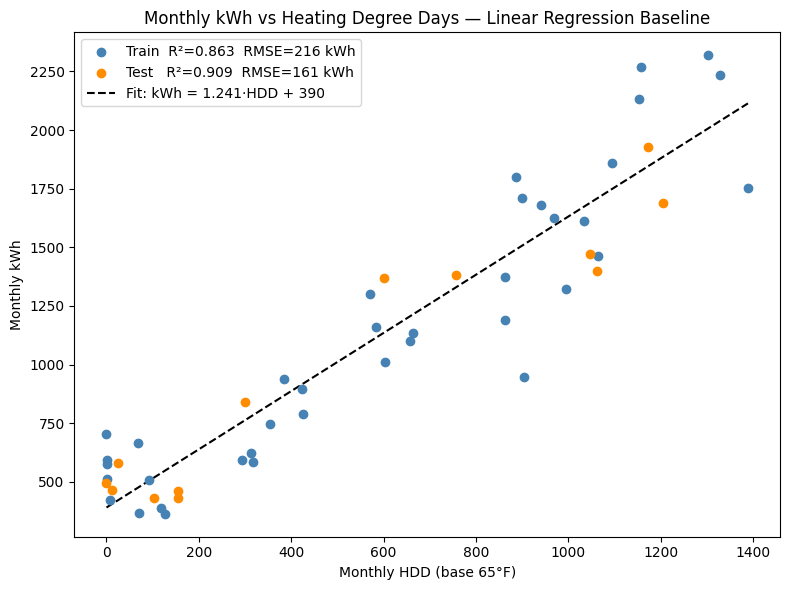

In [3]:
# --- kWh vs HDD scatter with regression line ---
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(train["hdd"], train["kwh"], color="steelblue", zorder=3,
           label=f"Train  R²={train_r2:.3f}  RMSE={train_rmse:.0f} kWh")
ax.scatter(test["hdd"],  test["kwh"],  color="darkorange", zorder=3,
           label=f"Test   R²={test_r2:.3f}  RMSE={test_rmse:.0f} kWh")
ax.plot(hdd_range, kwh_pred_line, color="black", linewidth=1.5, linestyle="--",
        label=f"Fit: kWh = {model.coef_[0]:.3f}·HDD + {model.intercept_:.0f}")

ax.set_title("Monthly kWh vs Heating Degree Days — Linear Regression Baseline")
ax.set_xlabel("Monthly HDD (base 65°F)")
ax.set_ylabel("Monthly kWh")
ax.legend()
plt.tight_layout()
plt.show()

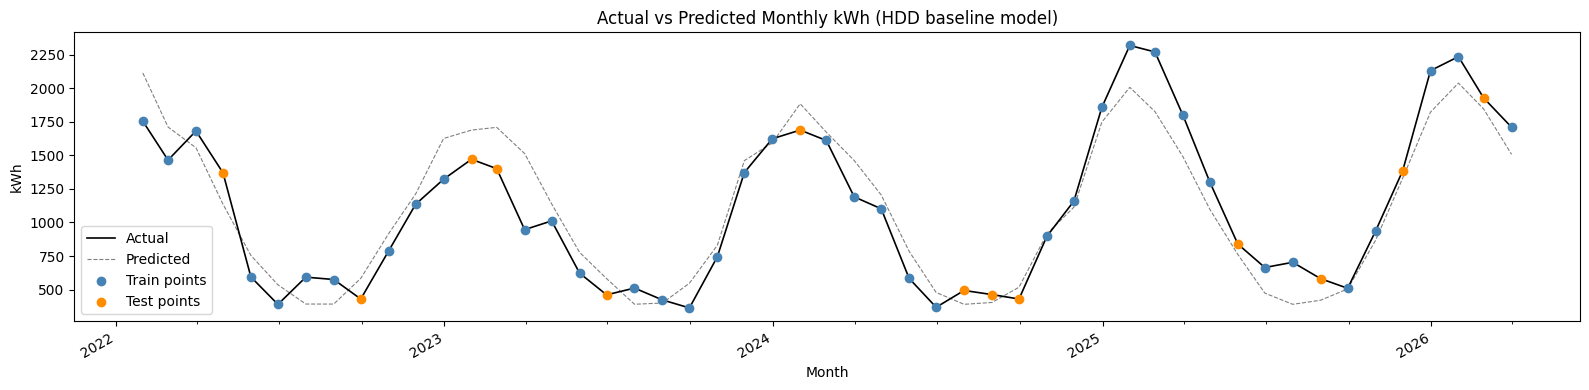

In [4]:
# --- Actual vs predicted over time (points colored by split) ---
df["pred"] = model.predict(df[["hdd"]])
df["split"] = "train"
df.loc[test.index, "split"] = "test"

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df.index, df["kwh"], color="black", linewidth=1.2, label="Actual", zorder=2)
ax.plot(df.index, df["pred"], color="gray", linewidth=0.8, linestyle="--", label="Predicted", zorder=1)

train_mask = df["split"] == "train"
test_mask  = df["split"] == "test"
ax.scatter(df.index[train_mask], df.loc[train_mask, "kwh"], color="steelblue",  zorder=3, label="Train points")
ax.scatter(df.index[test_mask],  df.loc[test_mask,  "kwh"], color="darkorange", zorder=3, label="Test points")

ax.set_title("Actual vs Predicted Monthly kWh (HDD baseline model)")
ax.set_xlabel("Month")
ax.set_ylabel("kWh")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [10]:
# --- Daily data prep ---
daily_kwh = elec.resample("D", on="timestamp")["kwh"].sum().rename("kwh")

df_daily = pd.merge(daily_hdd, daily_kwh, left_index=True, right_index=True).dropna()
df_daily["hdd"] = np.maximum(0, 65 - df_daily["temp_f"])


train_d, test_d = train_test_split(df_daily, test_size=0.25, random_state=42)

print(f"Total: {len(df_daily)} days")
print(f"Train: {len(train_d)} days")
print(f"Test:  {len(test_d)} days")
df_daily.head()

Total: 1549 days
Train: 1161 days
Test:  388 days


,temp_f,kwh,hdd
time,,,
2022-01-01,28.3650,34.262,36.6350
2022-01-02,28.1550,47.032,36.8450
2022-01-03,42.6675,48.584,22.3325
2022-01-04,49.7475,56.612,15.2525
2022-01-05,37.5375,43.300,27.4625


In [11]:
# --- Fit linear regression on daily training data ---
model_d = LinearRegression()
model_d.fit(train_d[["hdd"]], train_d["kwh"])

hdd_range_d = np.linspace(df_daily["hdd"].min(), df_daily["hdd"].max(), 200).reshape(-1, 1)
kwh_pred_line_d = model_d.predict(hdd_range_d)

train_pred_d = model_d.predict(train_d[["hdd"]])
test_pred_d  = model_d.predict(test_d[["hdd"]])

train_r2_d   = r2_score(train_d["kwh"], train_pred_d)
test_r2_d    = r2_score(test_d["kwh"],  test_pred_d)
train_rmse_d = root_mean_squared_error(train_d["kwh"], train_pred_d)
test_rmse_d  = root_mean_squared_error(test_d["kwh"],  test_pred_d)

print(f"Intercept: {model_d.intercept_:.1f} kWh")
print(f"Slope:     {model_d.coef_[0]:.4f} kWh / HDD")
print()
print(f"{'':10s}  {'R²':>6}  {'RMSE':>8}")
print(f"{'Train':10s}  {train_r2_d:6.3f}  {train_rmse_d:8.1f} kWh")
print(f"{'Test':10s}  {test_r2_d:6.3f}  {test_rmse_d:8.1f} kWh")

Intercept: 92.3 kWh
Slope:     -1.2253 kWh / HDD

                R²      RMSE
Train        0.730      12.0 kWh
Test         0.738      12.1 kWh


c:\Users\NickGarfield\AppData\Local\pypoetry\Cache\virtualenvs\neuralnets-project-kU7xEBzW-py3.11\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


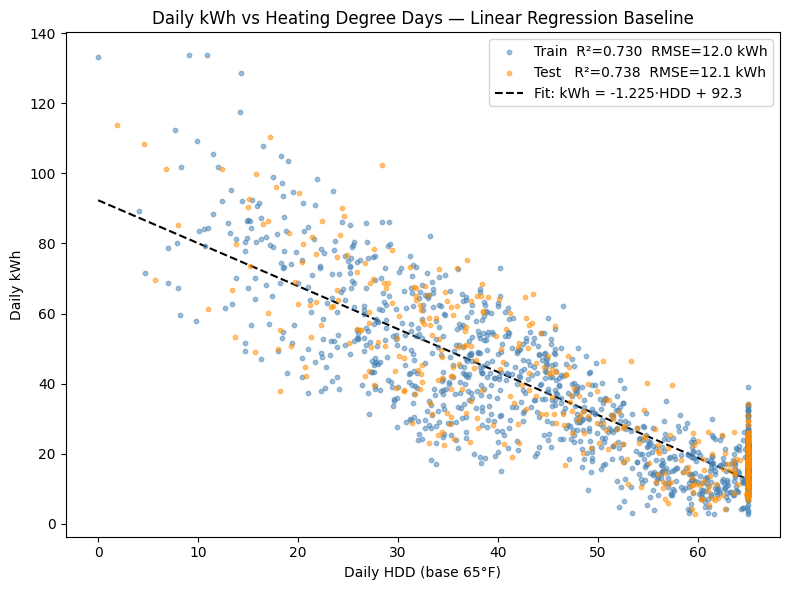

In [12]:
# --- Daily kWh vs HDD scatter with regression line ---
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(train_d["hdd"], train_d["kwh"], color="steelblue", s=10, alpha=0.5, zorder=3,
           label=f"Train  R²={train_r2_d:.3f}  RMSE={train_rmse_d:.1f} kWh")
ax.scatter(test_d["hdd"],  test_d["kwh"],  color="darkorange", s=10, alpha=0.5, zorder=3,
           label=f"Test   R²={test_r2_d:.3f}  RMSE={test_rmse_d:.1f} kWh")
ax.plot(hdd_range_d, kwh_pred_line_d, color="black", linewidth=1.5, linestyle="--",
        label=f"Fit: kWh = {model_d.coef_[0]:.3f}·HDD + {model_d.intercept_:.1f}")

ax.set_title("Daily kWh vs Heating Degree Days — Linear Regression Baseline")
ax.set_xlabel("Daily HDD (base 65°F)")
ax.set_ylabel("Daily kWh")
ax.legend()
plt.tight_layout()
plt.show()

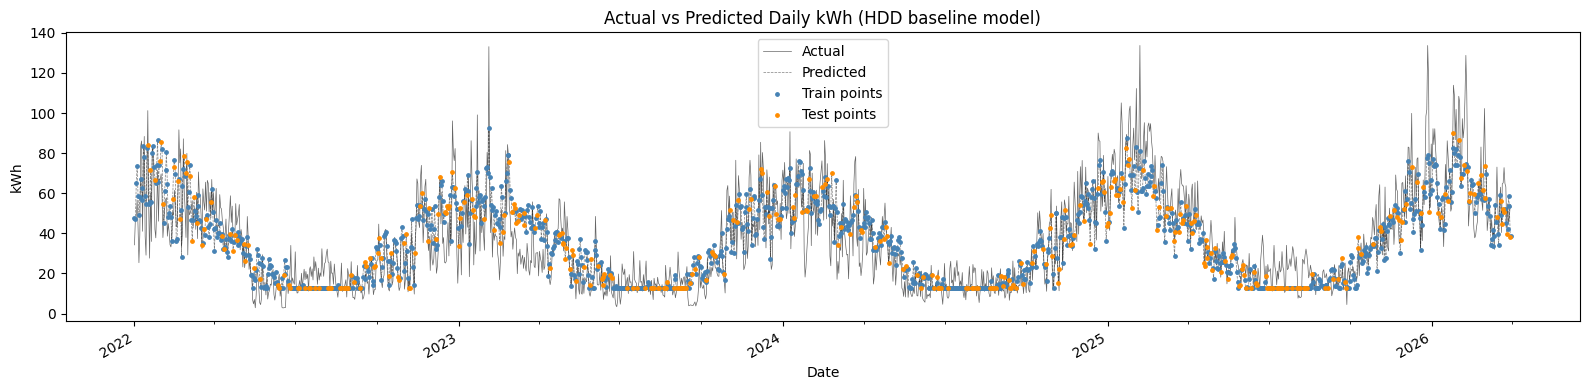

In [13]:
# --- Daily actual vs predicted over time ---
df_daily["pred"] = model_d.predict(df_daily[["hdd"]])
df_daily["split"] = "train"
df_daily.loc[test_d.index, "split"] = "test"

train_mask_d = df_daily["split"] == "train"
test_mask_d  = df_daily["split"] == "test"

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_daily.index, df_daily["kwh"], color="black", linewidth=0.5, alpha=0.6, label="Actual", zorder=2)
ax.plot(df_daily.index, df_daily["pred"], color="gray", linewidth=0.5, linestyle="--", label="Predicted", zorder=1)
ax.scatter(df_daily.index[train_mask_d], df_daily.loc[train_mask_d, "pred"],
           color="steelblue",  s=6, zorder=3, label="Train points")
ax.scatter(df_daily.index[test_mask_d],  df_daily.loc[test_mask_d,  "pred"],
           color="darkorange", s=6, zorder=3, label="Test points")

ax.set_title("Actual vs Predicted Daily kWh (HDD baseline model)")
ax.set_xlabel("Date")
ax.set_ylabel("kWh")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()